<a href="https://colab.research.google.com/github/HitenKumar786/Cloud-Computing-Google-Cloud/blob/main/MetroEnergy%20Solutions%20(MES)%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [23]:
df = pd.read_csv("household_power_consumption.csv")

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  object 
 1   Time                   1048575 non-null  object 
 2   Global_active_power    1048575 non-null  object 
 3   Global_reactive_power  1048575 non-null  object 
 4   Voltage                1048575 non-null  object 
 5   Global_intensity       1048575 non-null  object 
 6   Sub_metering_1         1048575 non-null  object 
 7   Sub_metering_2         1048575 non-null  object 
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


In [25]:
df.describe()

,Sub_metering_3
count,1.044506e+06
mean,5.933837e+00
std,8.210398e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [26]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,4069


In [27]:
df = df.replace('?', np.nan)

In [28]:
cols = [
'Global_active_power',
'Global_reactive_power',
'Voltage',
'Global_intensity',
'Sub_metering_1',
'Sub_metering_2',
'Sub_metering_3'
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [29]:
df = df.dropna()

In [30]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [31]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time']
)

df.head()

/tmp/ipykernel_686/2418887334.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Datetime'] = pd.to_datetime(


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [32]:
sample = df.head(5000)
print(sample)

            Date      Time  Global_active_power  Global_reactive_power  \
0     16/12/2006  17:24:00                4.216                  0.418   
1     16/12/2006  17:25:00                5.360                  0.436   
2     16/12/2006  17:26:00                5.374                  0.498   
3     16/12/2006  17:27:00                5.388                  0.502   
4     16/12/2006  17:28:00                3.666                  0.528   
...          ...       ...                  ...                    ...   
4995  20/12/2006   4:39:00                0.414                  0.258   
4996  20/12/2006   4:40:00                0.392                  0.250   
4997  20/12/2006   4:41:00                0.388                  0.248   
4998  20/12/2006   4:42:00                0.310                  0.144   
4999  20/12/2006   4:43:00                0.308                  0.144   

      Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  \
0      234.84              18.4             

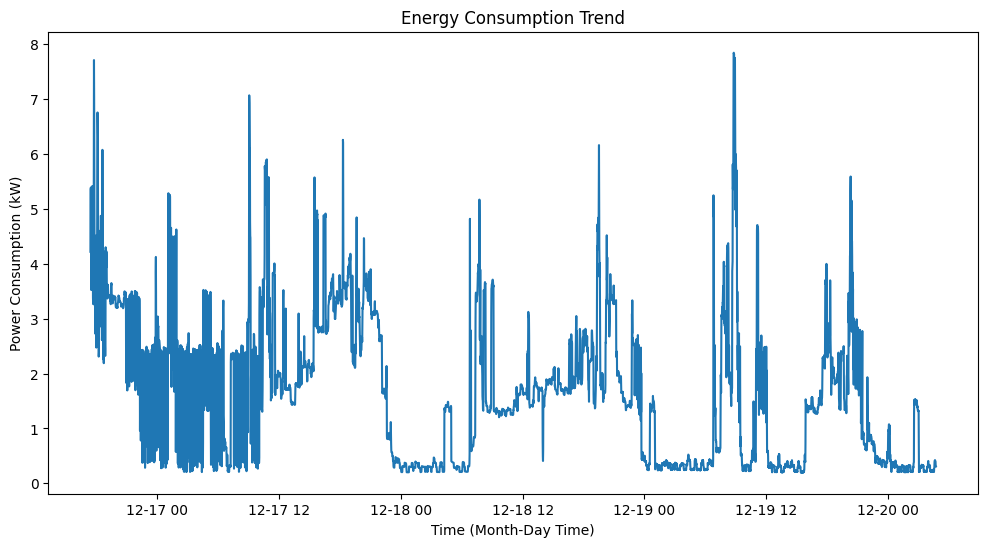

In [33]:
#Daily Consumption Trend

plt.figure(figsize=(12,6))

plt.plot(
    sample['Datetime'],
    sample['Global_active_power']
)

plt.title("Energy Consumption Trend")
plt.xlabel("Time (Month-Day Time)")
plt.ylabel("Power Consumption (kW)")

plt.show()

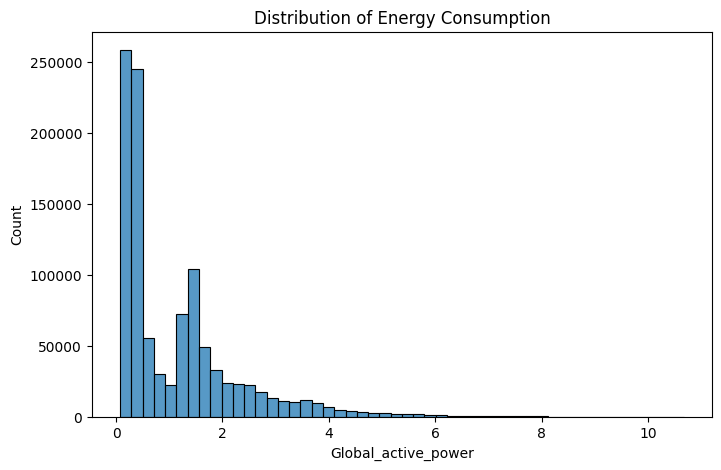

In [34]:
# Energy Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Global_active_power'],
    bins=50
)

plt.title("Distribution of Energy Consumption")

plt.show()

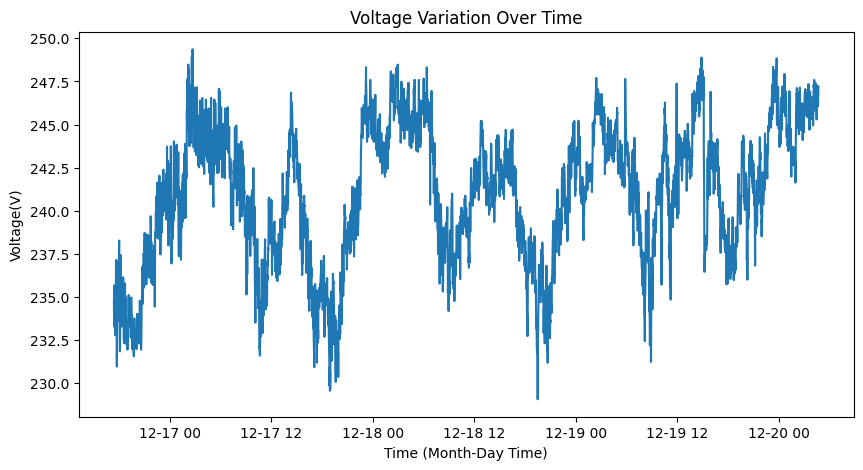

In [53]:
# Voltage Analysis

plt.figure(figsize=(10,5))

plt.plot(
    sample['Datetime'],
    sample['Voltage']
)

plt.title("Voltage Variation Over Time")
plt.xlabel("Time (Month-Day Time)")
plt.ylabel("Voltage(V)")

plt.show()

In [36]:
# Peak Consumption Detection

peak = df['Global_active_power'].max()

print("Peak Consumption =", peak,'kW')

Peak Consumption = 10.67 kW


In [40]:
# Create Forecasting Dataset

df['Hour'] = df['Datetime'].dt.hour
df[['Hour','Global_active_power']].head()

,Hour,Global_active_power
0,17,4.216
1,17,5.360
2,17,5.374
3,17,5.388
4,17,3.666


In [41]:
# Train Forecasting Model
X = df[['Hour']]
y = df['Global_active_power']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [44]:
predictions = model.predict(X_test)

In [45]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE =", mae)

MAE = 0.8120328368275737


AttributeError: 'Text' object has no attribute 'lower'

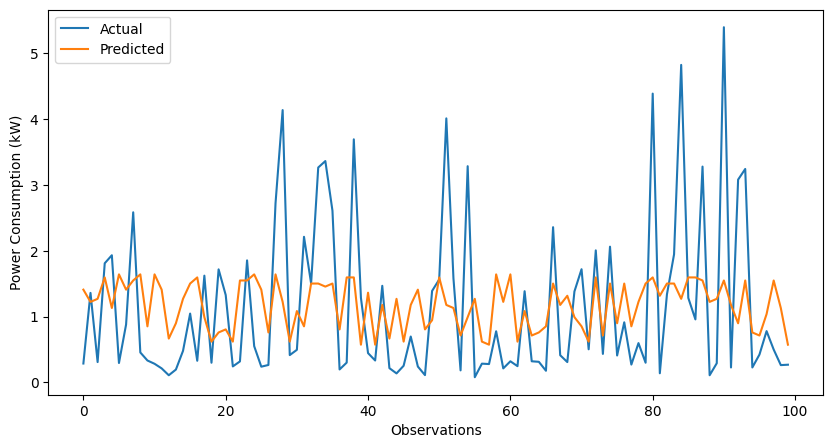

In [52]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    predictions[:100],
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Energy Consumption",
    plt.xlabel("Observations"),
    plt.ylabel("Power Consumption (kW)")
)

plt.show()